# 01 - The Subscription Landscape

**Day 3, descriptive analytics.** Who actually subscribes to a term deposit? This notebook profiles the *demographic* surface: job, age, education, marital status and financial standing. Demographics live in `marts.mart_customers` (one row per contact); the campaign/contact features are profiled in `02_campaign_strategy.ipynb`.

Everything is anchored to the **overall base rate of 11.3%**. These are *correlations*, surface patterns in who said yes. Whether any is *causal* is deferred to the Day 5 analysis and flagged where it matters.

In [1]:
# Day 3 setup: connect to BigQuery (service account, not user auth) and prepare
# the figure directory. Every number below is queried from the warehouse marts,
# never from a local CSV.
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account

sns.set_theme(style="whitegrid", context="talk")

# Repo paths, resolved relative to this notebook (notebooks/).
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
KEYFILE = REPO / "credentials" / "service-account.json"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PROJECT = json.loads(KEYFILE.read_text())["project_id"]
CREDS = service_account.Credentials.from_service_account_file(str(KEYFILE))
client = bigquery.Client(project=PROJECT, credentials=CREDS, location="US")
MARTS = f"{PROJECT}.marts"

# Anchor for the whole project: the overall subscription base rate.
BASE_RATE = (
    client.query(
        f"select avg(cast(subscribed as int64)) r from `{MARTS}.mart_campaign_outcomes`"
    )
    .to_dataframe()["r"]
    .iloc[0]
)


def rate_by(table, dim, where=None, order_by_rate=True):
    """Subscription rate, contact count and subscriber count grouped by `dim`."""
    clause = f"where {where}" if where else ""
    order = "order by rate desc" if order_by_rate else f"order by {dim}"
    sql = f"""
        select {dim},
               count(*)                       as n,
               countif(subscribed)            as n_subscribed,
               avg(cast(subscribed as int64)) as rate
        from `{MARTS}.{table}`
        {clause}
        group by {dim}
        {order}
    """
    return client.query(sql).to_dataframe()


def save(fig, name):
    """Write a figure to reports/figures/ at print resolution."""
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved -> {path.relative_to(REPO)}")


def annotate_rate(ax, base=BASE_RATE):
    """Draw the base-rate reference line every chart should be read against."""
    ax.axhline(base, color="crimson", linestyle="--", linewidth=1.5,
               label=f"base rate {base:.1%}")
    ax.legend(loc="best", fontsize=11)


def pct(v, _=None):
    return f"{v:.0%}"


print(f"project={PROJECT}  base subscription rate = {BASE_RATE:.4f} ({BASE_RATE:.1%})")


C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


project=bank-campaign-causal  base subscription rate = 0.1127 (11.3%)


## The anchor: overall subscription rate

Before any segment cut, fix the number every later finding is measured against.

In [2]:
overall = client.query(f"""
    select count(*) as contacts,
           countif(subscribed) as subscribers,
           avg(cast(subscribed as int64)) as rate
    from `{MARTS}.mart_campaign_outcomes`
""").to_dataframe()
overall.style.format({"contacts": "{:,}", "subscribers": "{:,}", "rate": "{:.1%}"})

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,contacts,subscribers,rate
0,"41,188","4,640",11.3%


_Caption: 4,640 of 41,188 contacts subscribed, a **base rate of 11.3%**. Read every segment rate below as a multiple of this anchor._

## Subscription rate by job x age bucket

The two strongest demographic axes, crossed.

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


saved -> reports\figures\subscription_rate_by_job_age.png


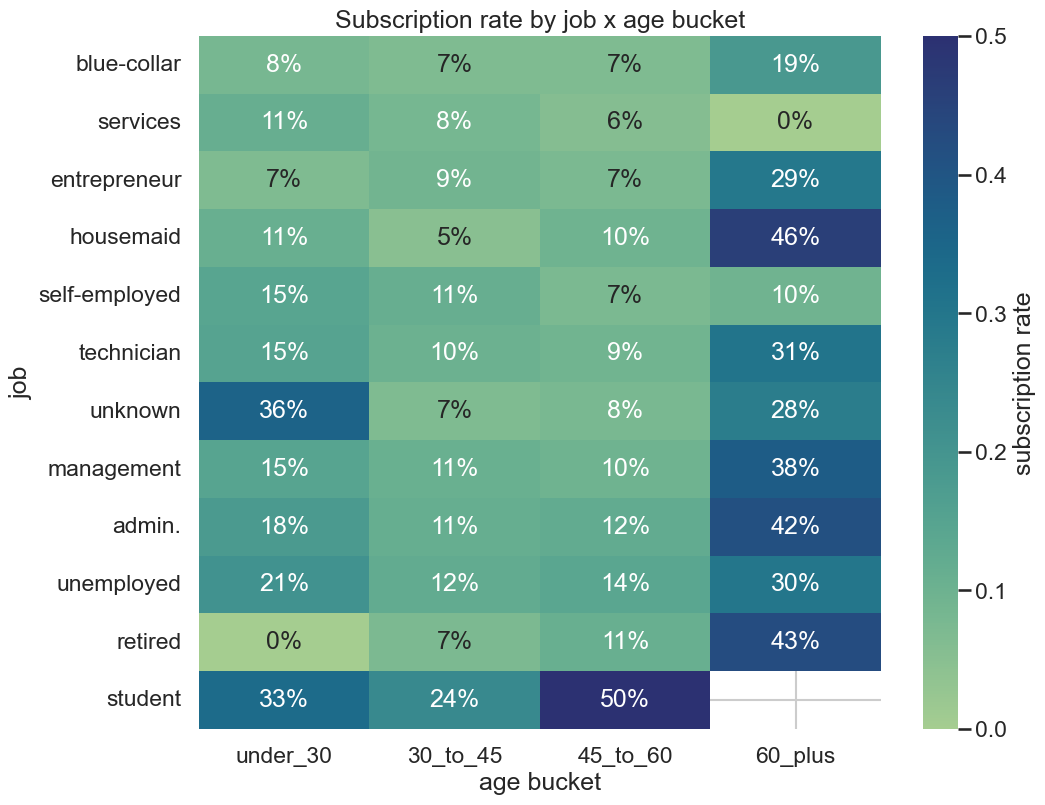

In [3]:
ja = client.query(f"""
    select job, age_bucket,
           count(*) as n,
           avg(cast(subscribed as int64)) as rate
    from `{MARTS}.mart_customers`
    group by job, age_bucket
""").to_dataframe()

# Order rows by each job's overall rate so the eye reads worst -> best.
age_order = ["under_30", "30_to_45", "45_to_60", "60_plus"]
job_rate = ja.groupby("job").apply(
    lambda d: (d["rate"] * d["n"]).sum() / d["n"].sum(), include_groups=False
)
job_order = job_rate.sort_values().index.tolist()
pivot = (ja.pivot(index="job", columns="age_bucket", values="rate")
           .reindex(index=job_order, columns=age_order))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="crest",
            cbar_kws={"label": "subscription rate"}, ax=ax)
ax.set_title("Subscription rate by job x age bucket")
ax.set_xlabel("age bucket"); ax.set_ylabel("job")
save(fig, "subscription_rate_by_job_age.png")
plt.show()

_Caption: rate climbs sharply toward the corners, students and the 60+ retired band convert far above the 11.3% base, blue-collar/services far below. Notice that **age and job are entangled** (most 60+ clients are retired); the heatmap shows association, not the independent effect of either, disentangling them is Day 5 work._

## Subscription rate by education

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


saved -> reports\figures\subscription_rate_by_education.png


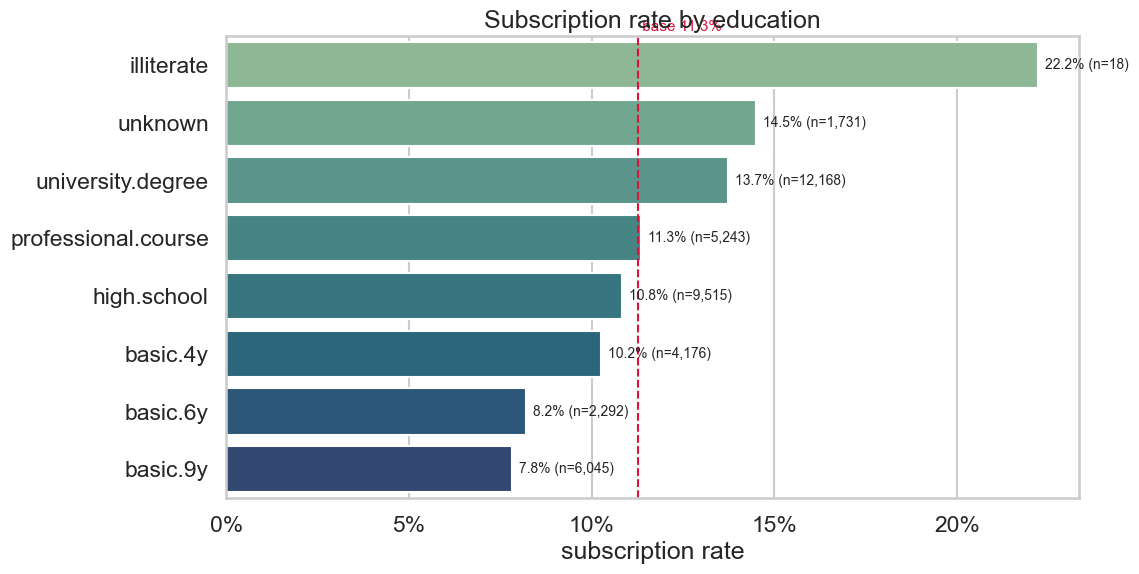

In [4]:
edu = rate_by("mart_customers", "education")
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=edu, x="rate", y="education", hue="education",
            palette="crest", legend=False, ax=ax)
ax.axvline(BASE_RATE, color="crimson", linestyle="--", linewidth=1.5)
ax.text(BASE_RATE, -0.6, f" base {BASE_RATE:.1%}", color="crimson", fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(pct))
for i, row in edu.iterrows():
    ax.text(row["rate"] + 0.002, i, f"{row['rate']:.1%} (n={row['n']:,})",
            va="center", fontsize=10)
ax.set_title("Subscription rate by education")
ax.set_xlabel("subscription rate"); ax.set_ylabel("")
save(fig, "subscription_rate_by_education.png")
plt.show()

_Caption: university-degree holders (13.7%) lead the mainstream categories; basic.9y trails at 7.8%. The `illiterate` bar (22%) sits on **n=18**, noise, not a finding. Education also proxies for age and job, so this is correlation, not an isolated effect._

## Subscription rate by marital status

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


saved -> reports\figures\subscription_rate_by_marital.png


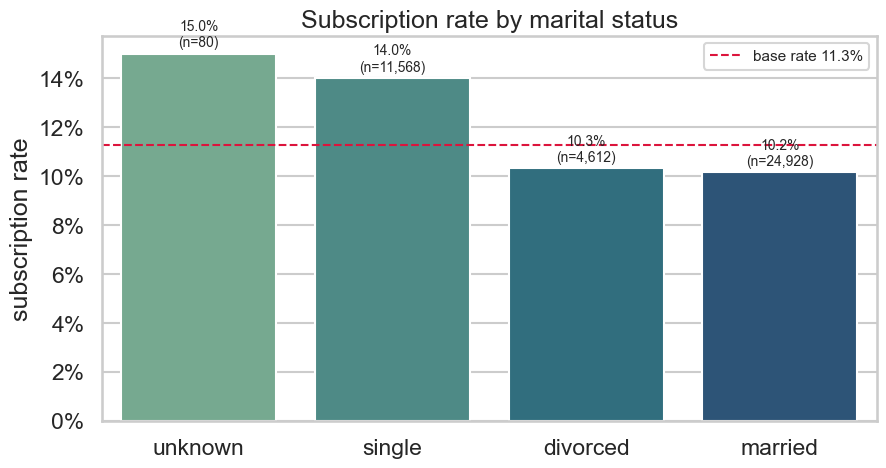

In [5]:
mar = rate_by("mart_customers", "marital")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=mar, x="marital", y="rate", hue="marital",
            palette="crest", legend=False, ax=ax)
annotate_rate(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct))
for i, row in mar.iterrows():
    ax.text(i, row["rate"] + 0.003, f"{row['rate']:.1%}\n(n={row['n']:,})",
            ha="center", fontsize=10)
ax.set_title("Subscription rate by marital status")
ax.set_xlabel(""); ax.set_ylabel("subscription rate")
save(fig, "subscription_rate_by_marital.png")
plt.show()

_Caption: single clients subscribe at 14.0% vs 10.2% for married, a modest 1.4x gap that largely tracks age (singles skew younger). Not a lever on its own; correlation, revisited on Day 5._

## Subscription rate by financial standing

Housing loan, personal loan, and credit default.

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,attribute,value,n,n_subscribed,rate
0,has_housing_loan,False,"19,612","2,133",10.9%
1,has_housing_loan,True,"21,576","2,507",11.6%
2,has_personal_loan,False,"34,940","3,957",11.3%
3,has_personal_loan,True,"6,248",683,10.9%
4,has_default,False,"41,185","4,640",11.3%
5,has_default,True,3,0,0.0%


saved -> reports\figures\subscription_rate_by_financial.png


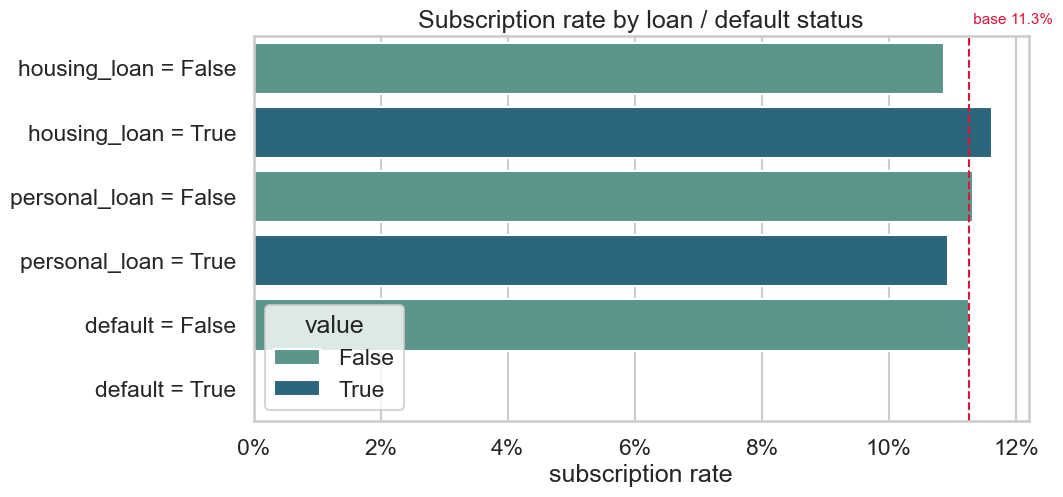

In [6]:
rows = []
for col in ["has_housing_loan", "has_personal_loan", "has_default"]:
    d = rate_by("mart_customers", col, order_by_rate=False).rename(columns={col: "value"})
    d["attribute"] = col
    rows.append(d)
fin = pd.concat(rows, ignore_index=True)[["attribute", "value", "n", "n_subscribed", "rate"]]
display(fin.style.format({"n": "{:,}", "n_subscribed": "{:,}", "rate": "{:.1%}"}))

fin["label"] = fin["attribute"].str.replace("has_", "") + " = " + fin["value"].astype(str)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=fin, x="rate", y="label", hue="value", palette="crest", ax=ax, dodge=False)
ax.axvline(BASE_RATE, color="crimson", linestyle="--", linewidth=1.5)
ax.text(BASE_RATE, -0.7, f" base {BASE_RATE:.1%}", color="crimson", fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(pct))
ax.set_title("Subscription rate by loan / default status")
ax.set_xlabel("subscription rate"); ax.set_ylabel("")
save(fig, "subscription_rate_by_financial.png")
plt.show()

_Caption: financial flags barely move the needle, housing (11.6% vs 10.9%) and personal loan (10.9% vs 11.3%) hug the base rate. `default` is effectively constant: only **3 of 41,188** clients are flagged, so its 0% rate is meaningless. Weak demographic signals at best._

## Top 3 and bottom 3 segments by conversion

Segments defined at the **job** level (each n is large enough to trust). This is the headline demographic spread.

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


TOP 3 segments:
  student       31.4% (n=875)  -> 2.8x base
  retired       25.2% (n=1,720)  -> 2.2x base
  unemployed    14.2% (n=1,014)  -> 1.3x base
BOTTOM 3 segments:
  entrepreneur  8.5% (n=1,456)  -> 0.8x base
  services      8.1% (n=3,969)  -> 0.7x base
  blue-collar   6.9% (n=9,254)  -> 0.6x base

Spread: student converts 4.6x more often than blue-collar.


saved -> reports\figures\subscription_rate_top_bottom_segments.png


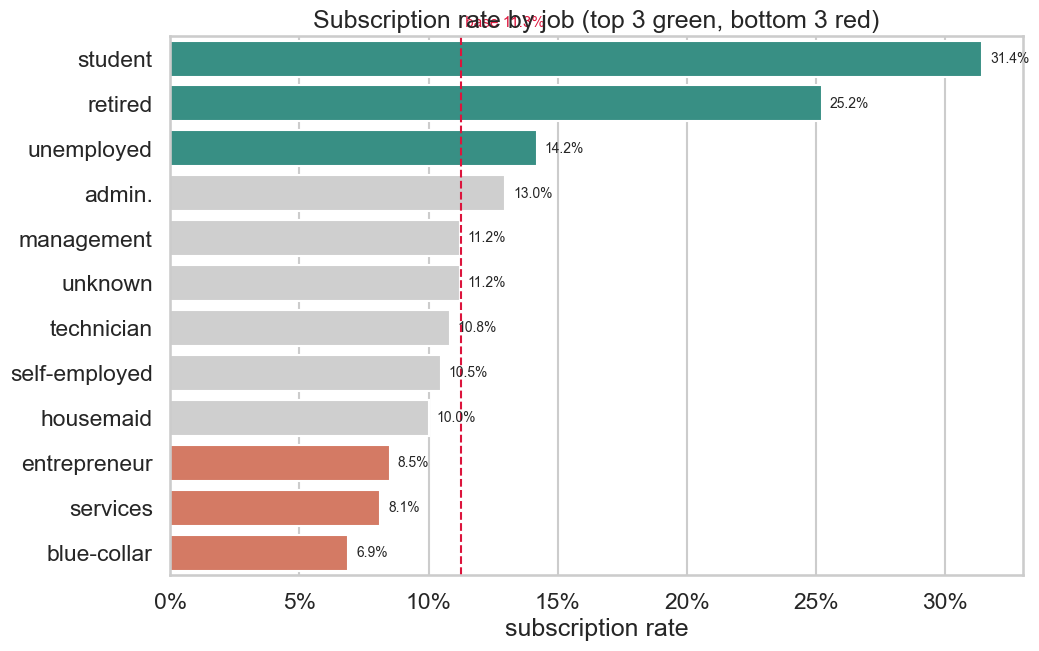

In [7]:
job = rate_by("mart_customers", "job")
top3, bot3 = job.head(3), job.tail(3)
print("TOP 3 segments:")
for _, r in top3.iterrows():
    print(f"  {r['job']:13} {r['rate']:.1%} (n={r['n']:,})  -> {r['rate']/BASE_RATE:.1f}x base")
print("BOTTOM 3 segments:")
for _, r in bot3.iterrows():
    print(f"  {r['job']:13} {r['rate']:.1%} (n={r['n']:,})  -> {r['rate']/BASE_RATE:.1f}x base")
spread = top3.iloc[0]["rate"] / bot3.iloc[-1]["rate"]
print(f"\nSpread: {top3.iloc[0]['job']} converts {spread:.1f}x more often than {bot3.iloc[-1]['job']}.")

top_set, bot_set = set(top3["job"]), set(bot3["job"])
colors = ["#2a9d8f" if j in top_set else "#e76f51" if j in bot_set else "#cfcfcf"
          for j in job["job"]]
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=job, x="rate", y="job", palette=colors, hue="job", legend=False, ax=ax)
ax.axvline(BASE_RATE, color="crimson", linestyle="--", linewidth=1.5)
ax.text(BASE_RATE, -0.7, f" base {BASE_RATE:.1%}", color="crimson", fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(pct))
for i, r in job.reset_index(drop=True).iterrows():
    ax.text(r["rate"] + 0.003, i, f"{r['rate']:.1%}", va="center", fontsize=10)
ax.set_title("Subscription rate by job (top 3 green, bottom 3 red)")
ax.set_xlabel("subscription rate"); ax.set_ylabel("")
save(fig, "subscription_rate_top_bottom_segments.png")
plt.show()

_Caption: **students (31.4%, n=875) and retired (25.2%, n=1,720) sit ~2.2-2.8x above base; blue-collar (6.9%, n=9,254) sits below it, a 4.6x top-to-bottom spread.** But the high-converting jobs are exactly the ones outside the workforce: job here may be a proxy for age and life stage, not an independent driver. Correlation, not causation, revisited on Day 5._

---
Findings are written up in `docs/findings.md` -> **Section 1: The Subscription Landscape**. Campaign *strategy* is profiled in `02_campaign_strategy.ipynb`.